In [ ]:
from transformers import pipeline

In [ ]:
# Encoder Only style tas - Classification
classifier = pipeline("sentiment-analysis")
print(classifier("I've been learning Hugging Face and I'm Finally starting to get it"))

In [ ]:
## Decoder only style task -  text generations
generator = pipeline("text-generation", model="gpt2")
print(generator("The future of AI engineering is", max_length=30))

In [ ]:

summarizer = pipeline("text-generation", model="Qwen/Qwen3-4B-Instruct-2507")

long_text = """Hugging Face is a company that has built the most widely used 
open-source ecosystem for machine learning. Its Hub hosts models, datasets, 
and demo apps, while its libraries like transformers and datasets make it 
simple to load and use state-of-the-art AI models with just a few lines of code."""

message_history = [
    {"role": "user", "content": f"Summarize the following text:\n\n{long_text}"}
]
result = summarizer(message_history)
print(result)

In [1]:
import torch
import torch.nn.functional as F

logits = torch.tensor([10.0, 8.0, 6.0, 4.0])

for T in [0.5, 1.0, 2.0, 5.0]:
    scaled = logits / T
    probs = F.softmax(scaled, dim=0)
    print(f"T={T}")
    print(f"  scaled logits: {scaled.tolist()}")
    print(f"  probabilities: {[round(p, 4) for p in probs.tolist()]}")
    print(f"  argmax token index: {torch.argmax(probs).item()}  <-- unchanged regardless of T")
    print()

# Prove ordering never changes, only the spread of probability mass
print("Order of logits (descending) is always:", torch.argsort(logits, descending=True).tolist())
for T in [0.5, 1.0, 2.0, 5.0]:
    probs = F.softmax(logits / T, dim=0)
    print(f"T={T} -> order of probs (descending):", torch.argsort(probs, descending=True).tolist())

print()
print("Now let's actually sample tokens many times to see 'creativity' emerge:")
torch.manual_seed(0)
for T in [0.5, 1.0, 2.0, 5.0]:
    probs = F.softmax(logits / T, dim=0)
    samples = torch.multinomial(probs, num_samples=1000, replacement=True)
    counts = torch.bincount(samples, minlength=4)
    freqs = counts.float() / 1000
    print(f"T={T}  sampled frequencies: {[round(f, 3) for f in freqs.tolist()]}")

T=0.5
  scaled logits: [20.0, 16.0, 12.0, 8.0]
  probabilities: [0.9817, 0.018, 0.0003, 0.0]
  argmax token index: 0  <-- unchanged regardless of T

T=1.0
  scaled logits: [10.0, 8.0, 6.0, 4.0]
  probabilities: [0.865, 0.1171, 0.0158, 0.0021]
  argmax token index: 0  <-- unchanged regardless of T

T=2.0
  scaled logits: [5.0, 4.0, 3.0, 2.0]
  probabilities: [0.6439, 0.2369, 0.0871, 0.0321]
  argmax token index: 0  <-- unchanged regardless of T

T=5.0
  scaled logits: [2.0, 1.600000023841858, 1.2000000476837158, 0.800000011920929]
  probabilities: [0.4131, 0.2769, 0.1856, 0.1244]
  argmax token index: 0  <-- unchanged regardless of T

Order of logits (descending) is always: [0, 1, 2, 3]
T=0.5 -> order of probs (descending): [0, 1, 2, 3]
T=1.0 -> order of probs (descending): [0, 1, 2, 3]
T=2.0 -> order of probs (descending): [0, 1, 2, 3]
T=5.0 -> order of probs (descending): [0, 1, 2, 3]

Now let's actually sample tokens many times to see 'creativity' emerge:
T=0.5  sampled frequencies: 

### Decoding Strategies for LLM

In [1]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model.eval()

text = "I have a dream"
input_ids = tokenizer.encode(text, return_tensors='pt').to(device)

outputs = model.generate(input_ids, max_length=len(input_ids.squeeze())+5)
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Generated text: {generated_text}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated text: I have a dream of being a doctor.


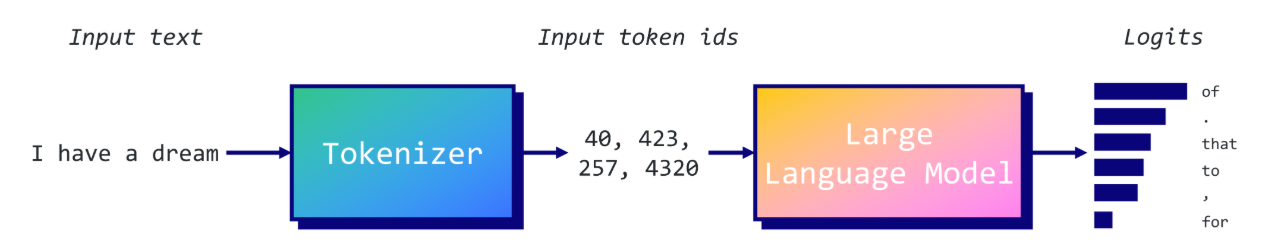

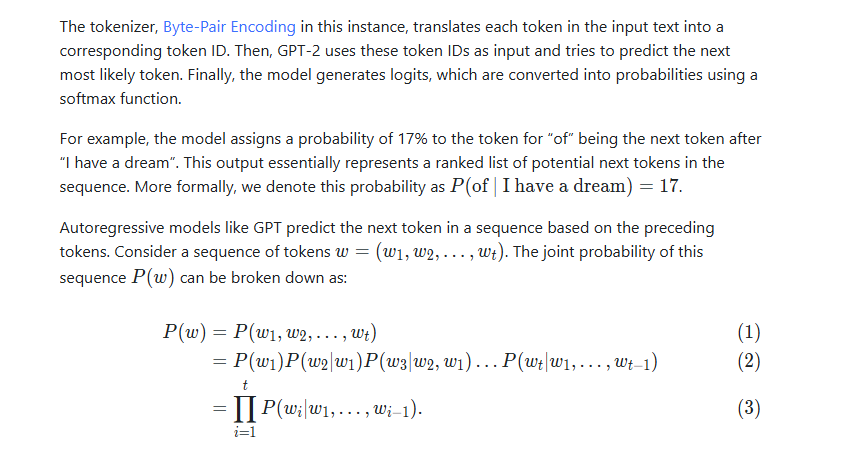

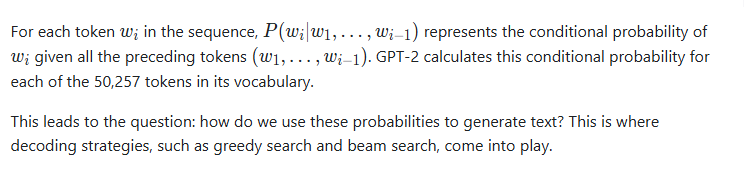

### Greedy Search / Greedy Decoding

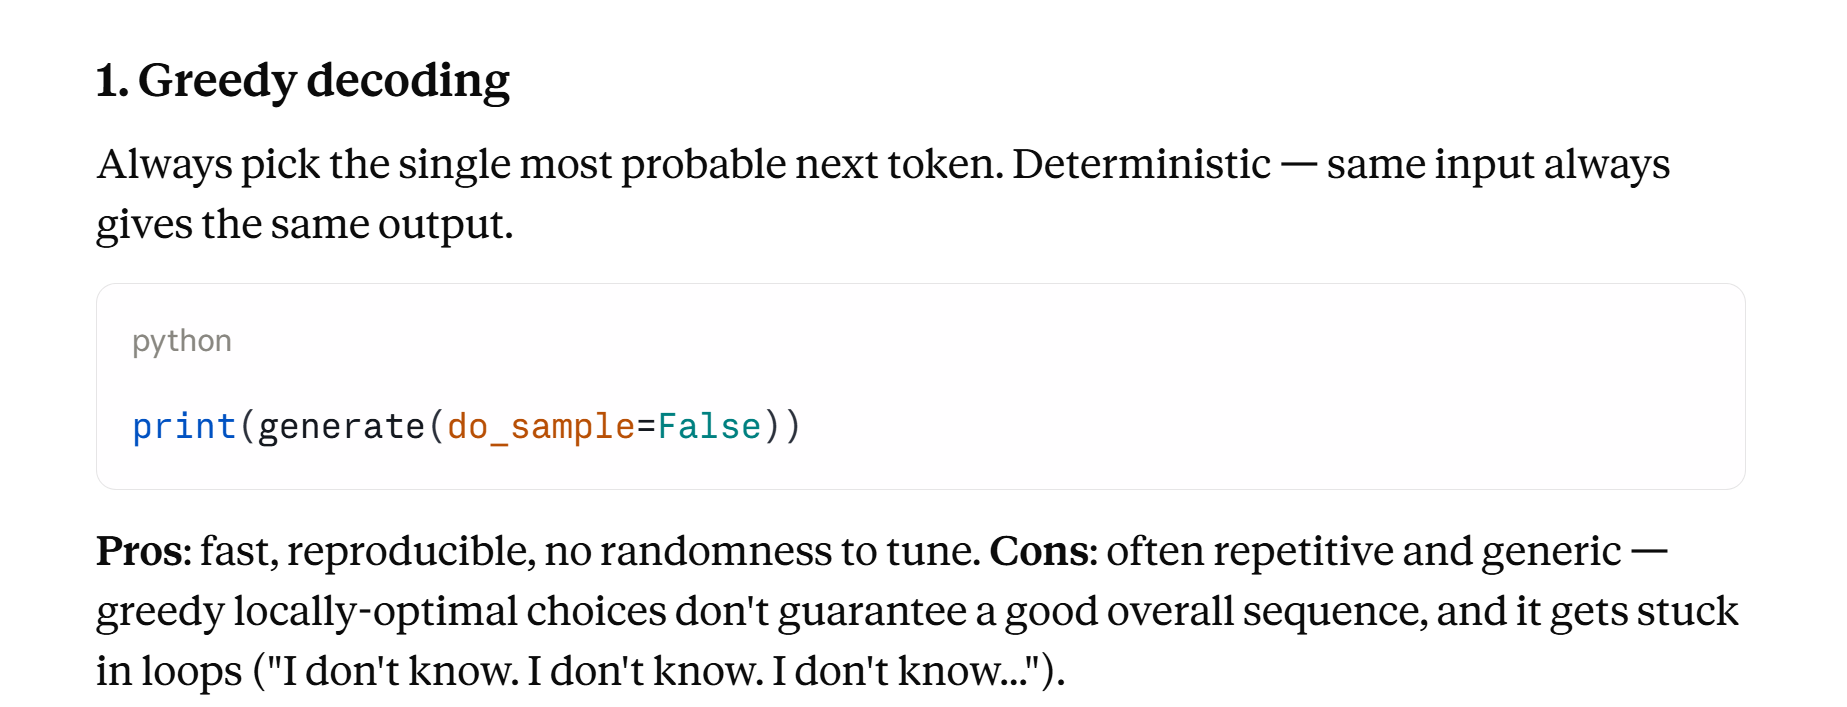

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import time

def get_log_prob(logits, token_id):
    # Compute the softmax of the logits
    probabilities = torch.nn.functional.softmax(logits, dim=-1)
    log_probabilities = torch.log(probabilities)
    
    # Get the log probability of the token
    token_log_probability = log_probabilities[token_id].item()
    return token_log_probability

def greedy_search(input_ids, node, length=5):
    if length == 0:
        return input_ids

    outputs = model(input_ids)
    predictions = outputs.logits

    # Get the predicted next sub-word (here we use top-k search)
    logits = predictions[0, -1, :]
    token_id = torch.argmax(logits).unsqueeze(0)

    # Compute the score of the predicted token
    token_score = get_log_prob(logits, token_id)

    # Add the predicted token to the list of input ids
    new_input_ids = torch.cat([input_ids, token_id.unsqueeze(0)], dim=-1)

    # Add node and edge to graph
    next_token = tokenizer.decode(token_id, skip_special_tokens=True)
    current_node = list(graph.successors(node))[0]
    graph.nodes[current_node]['tokenscore'] = np.exp(token_score) * 100
    graph.nodes[current_node]['token'] = next_token + f"_{length}"

    # Recursive call
    input_ids = greedy_search(new_input_ids, current_node, length-1)
    
    return input_ids

# Parameters
length = 5
beams = 1

# Create a balanced tree with height 'length'
graph = nx.balanced_tree(1, length, create_using=nx.DiGraph())

# Add 'tokenscore', 'cumscore', and 'token' attributes to each node
for node in graph.nodes:
    graph.nodes[node]['tokenscore'] = 100
    graph.nodes[node]['token'] = text

# Start generating text
output_ids = greedy_search(input_ids, 0, length=length)
output = tokenizer.decode(output_ids.squeeze().tolist(), skip_special_tokens=True)
print(f"Generated text: {output}")

Generated text: I have a dream of being a doctor.


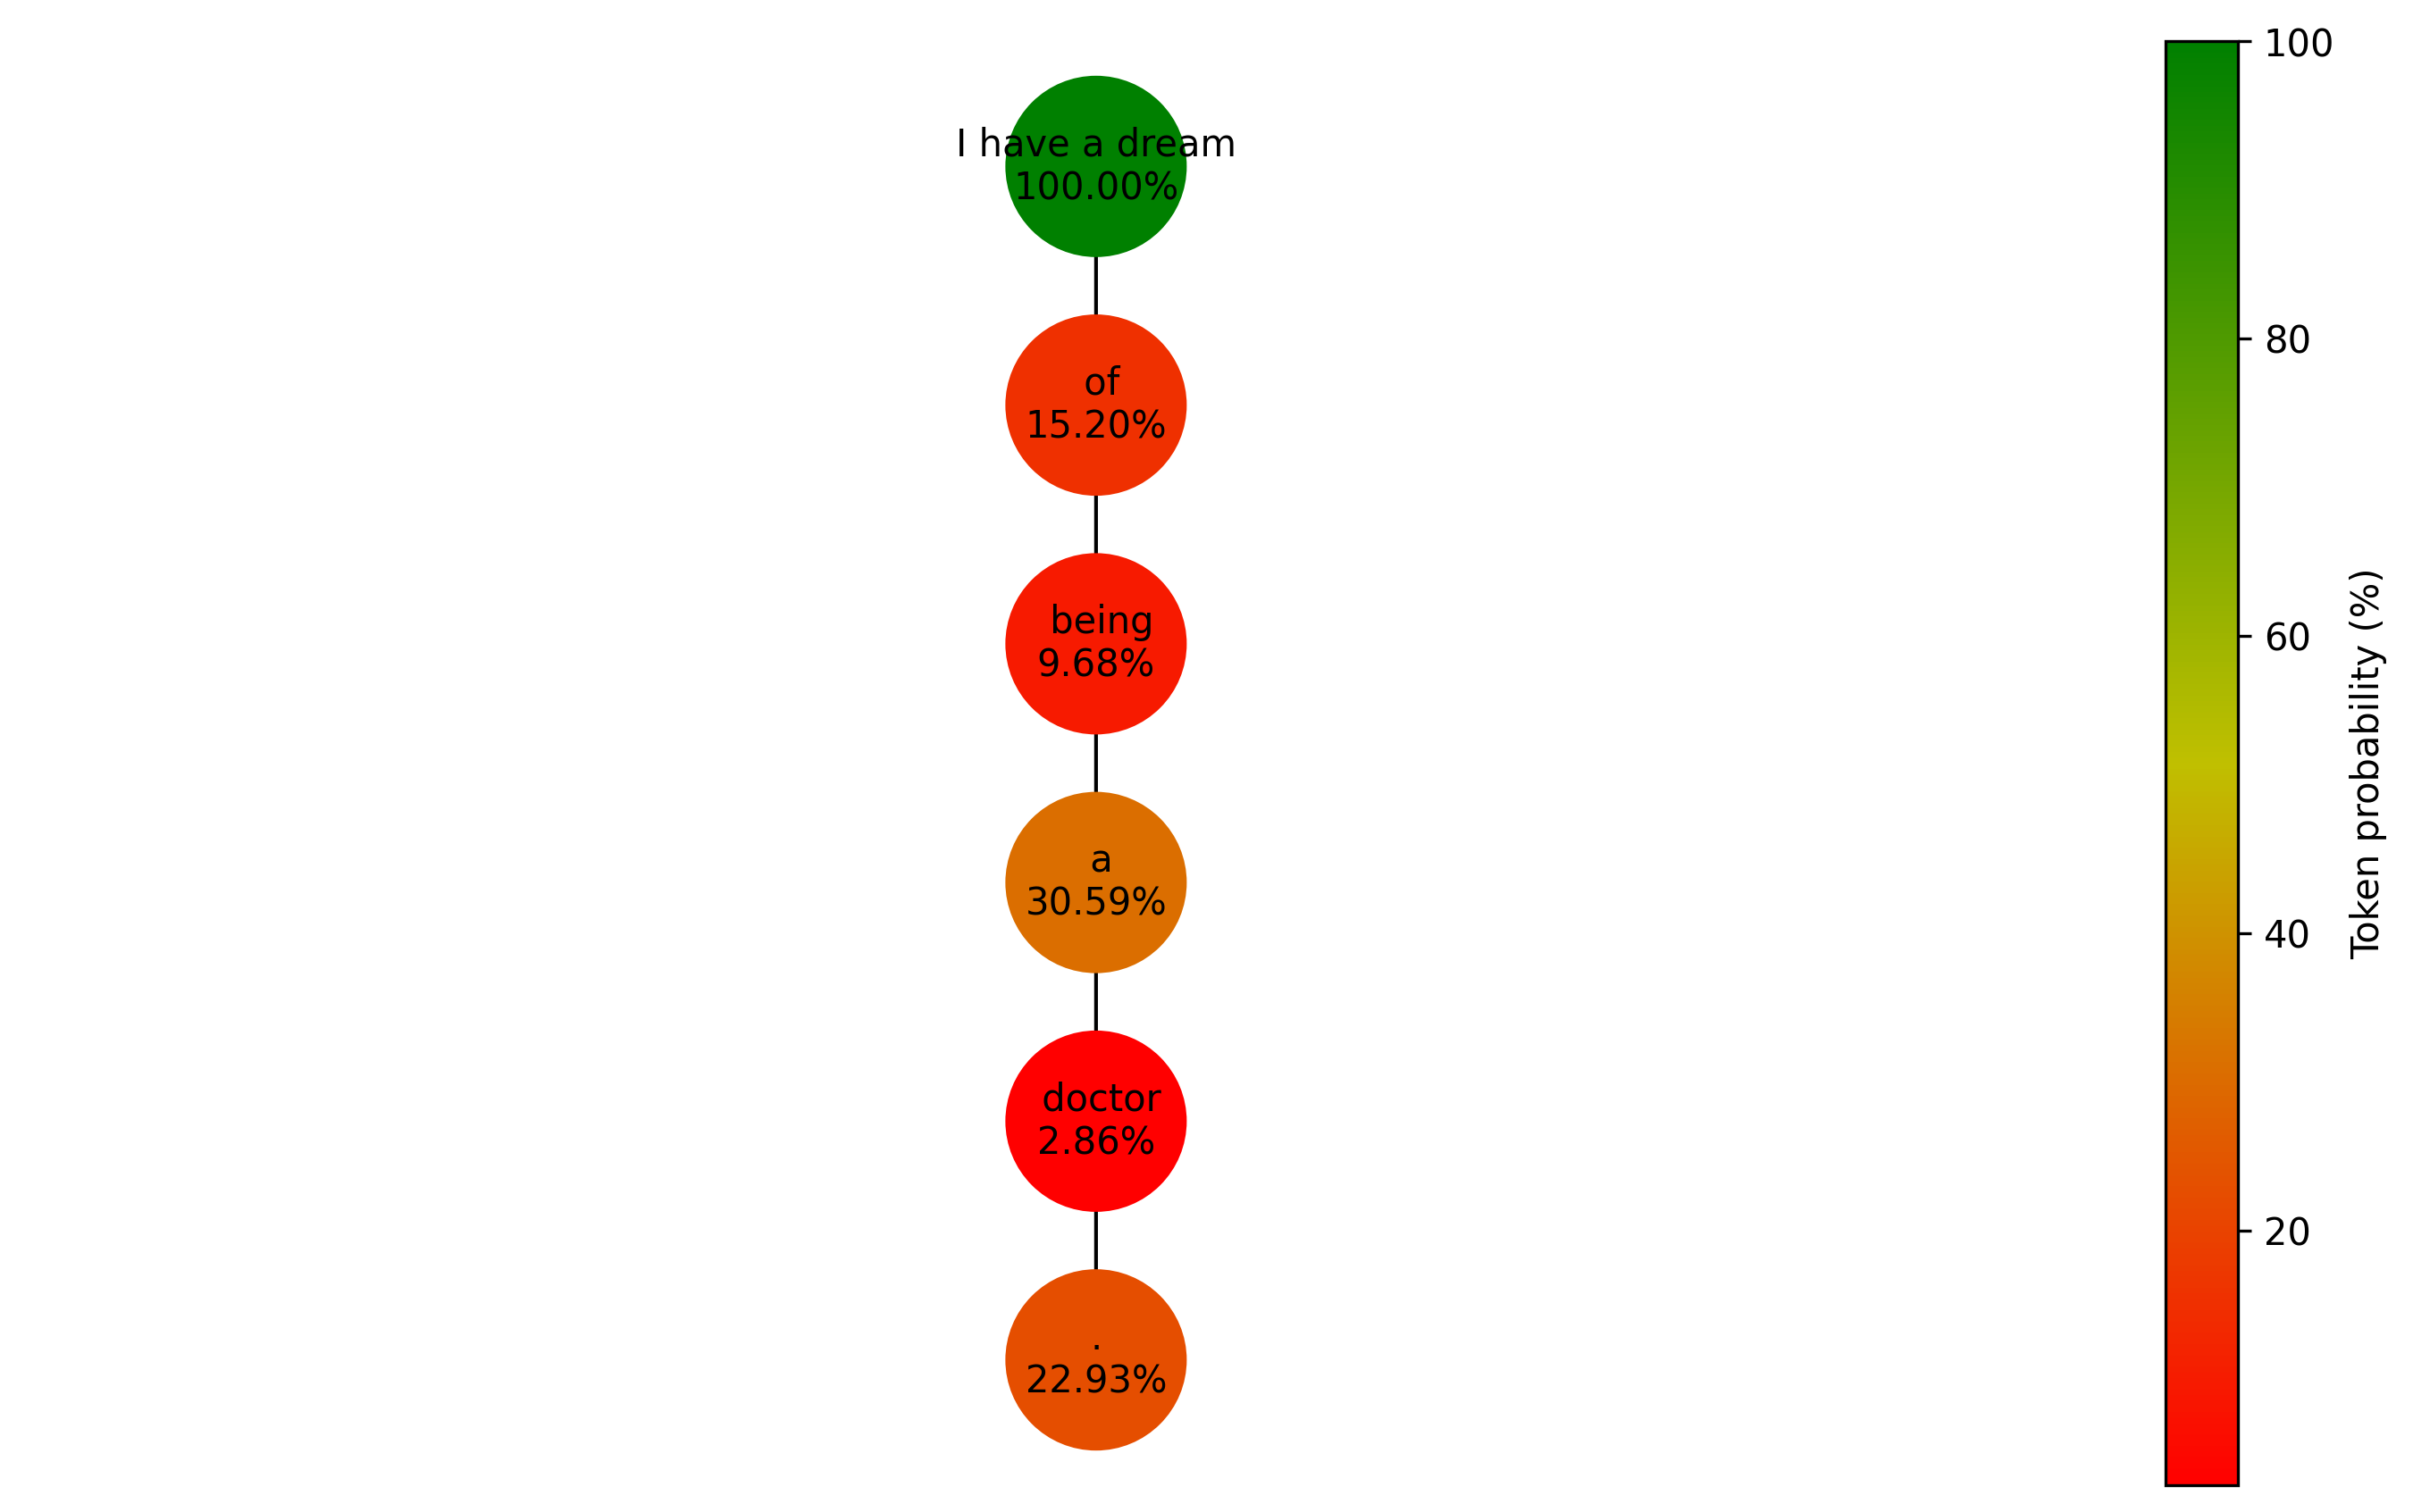

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

def plot_graph(graph, length, beams, score):
    fig, ax = plt.subplots(figsize=(3+1.2*beams**length, max(5, 2+length)), dpi=300, facecolor='white')

    # Create positions for each node
    pos = nx.nx_agraph.graphviz_layout(graph, prog="dot")

    # Normalize the colors along the range of token scores
    if score == 'token':
        scores = [data['tokenscore'] for _, data in graph.nodes(data=True) if data['token'] is not None]
    elif score == 'sequence':
        scores = [data['sequencescore'] for _, data in graph.nodes(data=True) if data['token'] is not None]
    vmin = min(scores)
    vmax = max(scores)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = LinearSegmentedColormap.from_list('rg', ["r", "y", "g"], N=256) 

    # Draw the nodes
    nx.draw_networkx_nodes(graph, pos, node_size=2000, node_shape='o', alpha=1, linewidths=4, 
                          node_color=scores, cmap=cmap)

    # Draw the edges
    nx.draw_networkx_edges(graph, pos)

    # Draw the labels
    if score == 'token':
        labels = {node: data['token'].split('_')[0] + f"\n{data['tokenscore']:.2f}%" for node, data in graph.nodes(data=True) if data['token'] is not None}
    elif score == 'sequence':
        labels = {node: data['token'].split('_')[0] + f"\n{data['sequencescore']:.2f}" for node, data in graph.nodes(data=True) if data['token'] is not None}
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=10)
    plt.box(False)

    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    if score == 'token':
        fig.colorbar(sm, ax=ax, orientation='vertical', pad=0, label='Token probability (%)')
    elif score == 'sequence':
        fig.colorbar(sm, ax=ax, orientation='vertical', pad=0, label='Sequence score')
    plt.show()

# Plot graph
plot_graph(graph, length, 1.5, 'token')

In [13]:
model_name = "gpt2"
# pip install transformers torch --break-system-packages   (if not already installed)

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "gpt2"  # small, fast, good for experimenting
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

prompt = "I have a dream"
inputs = tokenizer(prompt, return_tensors="pt")

def generate(**kwargs):
    torch.manual_seed(0)  # reproducibility for sampling-based methods
    output = model.generate(**inputs, max_new_tokens=len(inputs) + 3, pad_token_id=tokenizer.eos_token_id, **kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [14]:
print(generate(do_sample=False))

I have a dream of being a doctor.


In [15]:
print(inputs)

{'input_ids': tensor([[  40,  423,  257, 4320]]), 'attention_mask': tensor([[1, 1, 1, 1]])}


In [23]:
model(input_ids).logits.shape

torch.Size([1, 4, 50257])

In [22]:
tokenizer.decode(torch.argmax(model(input_ids).logits[0, -1, :]).unsqueeze(0), skip_special_tokens=True)

' of'

In [20]:
model(input_ids).logits

tensor([[[ -39.3084,  -39.0100,  -41.8374,  ...,  -46.9337,  -44.9074,
           -39.5149],
         [-120.8801, -121.5422, -126.6942,  ..., -124.8963, -123.2075,
          -123.6670],
         [-115.5008, -114.1117, -116.8476,  ..., -120.0942, -118.9152,
          -115.8024],
         [ -94.4954,  -95.4715, -103.7566,  ..., -107.9975, -107.7768,
           -98.6216]]], grad_fn=<UnsafeViewBackward0>)

In [24]:
outputs = model(input_ids)
logits = outputs.logits[0]  # shape [4, 50257], drop the batch dim

for i in range(4):
    top_token_id = torch.argmax(logits[i])
    predicted_word = tokenizer.decode(top_token_id)
    seen_so_far = tokenizer.decode(input_ids[0][:i+1])
    print(f"Row {i}: model has seen '{seen_so_far}' -> predicts next word: '{predicted_word}'")

Row 0: model has seen 'I' -> predicts next word: '.'
Row 1: model has seen 'I have' -> predicts next word: ' a'
Row 2: model has seen 'I have a' -> predicts next word: ' lot'
Row 3: model has seen 'I have a dream' -> predicts next word: ' of'


In [27]:
input_ids

tensor([[  40,  423,  257, 4320]])

In [29]:
torch.concat([input_ids, torch.tensor([234]).unsqueeze(0)], dim=-1)

tensor([[  40,  423,  257, 4320,  234]])

In [30]:
def greedy_search(model: AutoModelForCausalLM, tokenizer: AutoTokenizer, input_ids: torch.Tensor, max_token_length: int):
    if max_token_length == 0:
        return input_ids

    output = model(input_ids)
    prediction = output.logits
    logits = prediction[0, -1, :]
    token_id = torch.argmax(logits).unsqueeze(0)

    new_input_ids = torch.cat([input_ids, token_id.unsqueeze(0)], dim=-1)

    input_ids = greedy_search(model, tokenizer, new_input_ids, max_token_length - 1)
    return input_ids

# Start generating text
output_ids = greedy_search(model, tokenizer, input_ids, max_token_length=5)
output = tokenizer.decode(output_ids.squeeze().tolist(), skip_special_tokens=True)
print(f"Generated text: {output}")

Generated text: I have a dream of being a doctor.


Generated text: I have a dream of being a doctor.


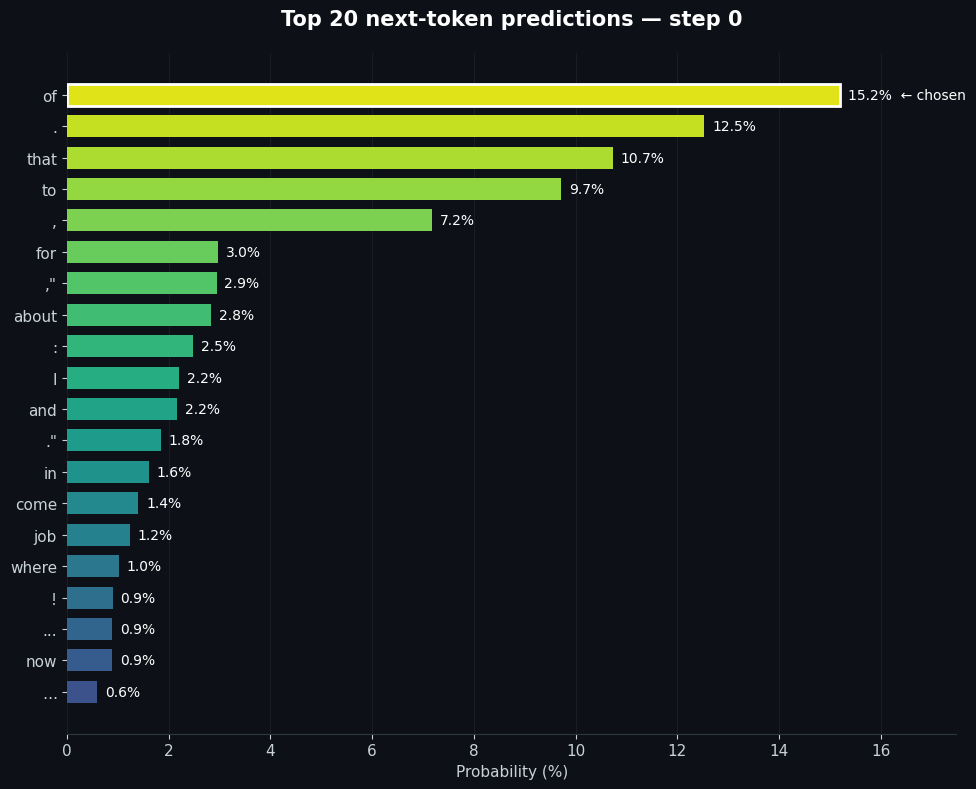

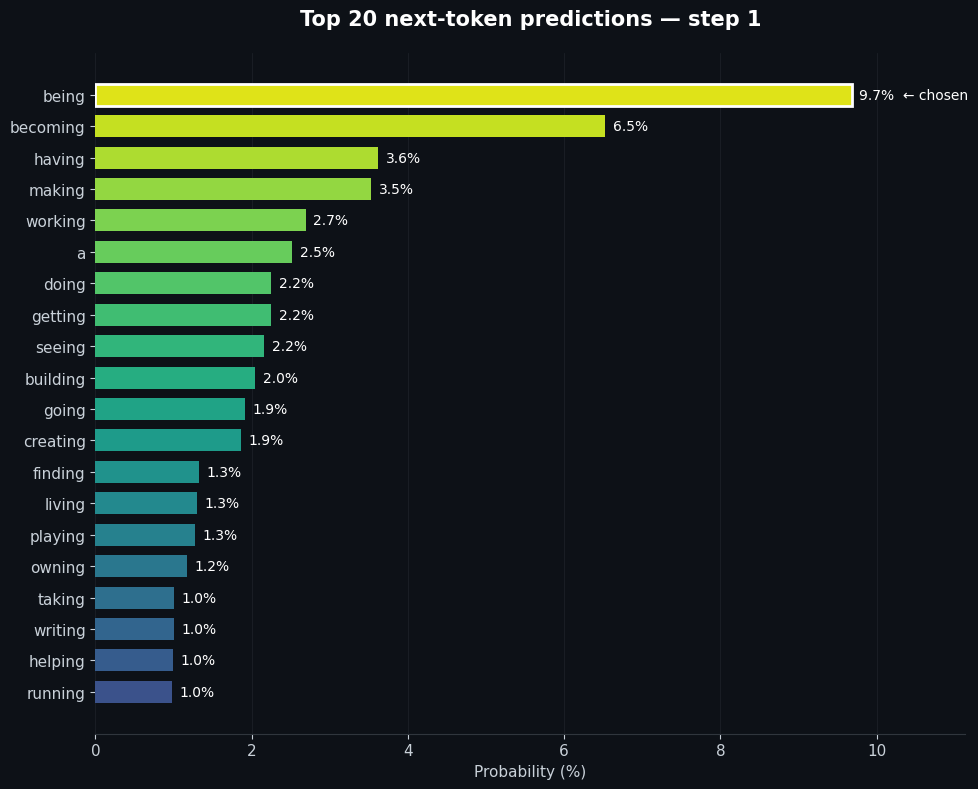

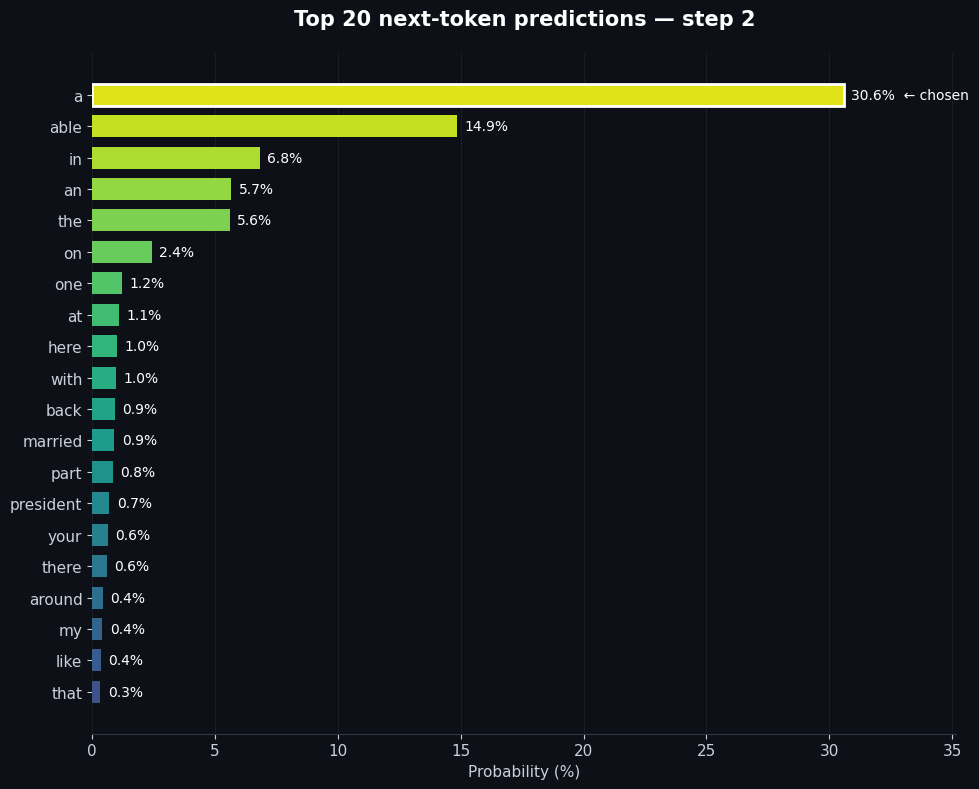

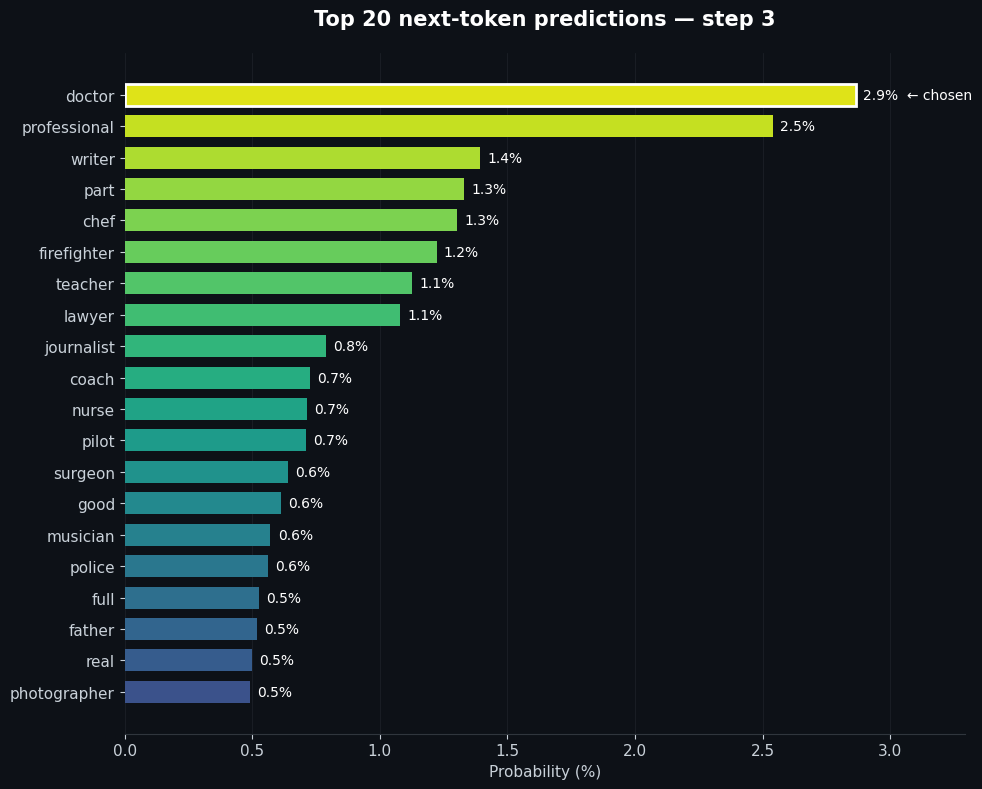

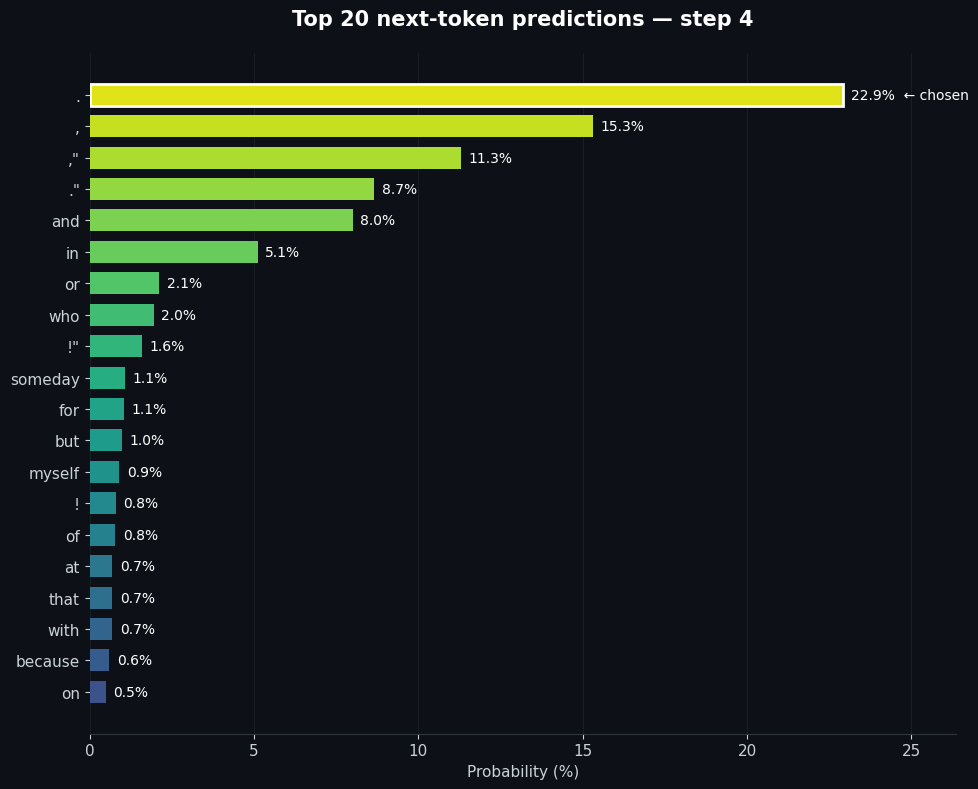

In [31]:
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


def greedy_search(model, tokenizer, input_ids: torch.Tensor, max_token_length: int, history: list = None):
    """
    Recursively generates tokens greedily, while recording the top-20
    probability distribution at each generation step into `history`.
    """
    if history is None:
        history = []  # only initialized once, on the outermost call

    if max_token_length == 0:
        return input_ids, history

    output = model(input_ids)
    logits = output.logits[0, -1, :]                     # last position only
    probs = torch.nn.functional.softmax(logits, dim=-1)   # convert to probabilities

    token_id = torch.argmax(logits).unsqueeze(0)           # greedy pick

    # Record top-20 for this step, before moving on
    top_probs, top_ids = torch.topk(probs, 20)
    step_tokens = [tokenizer.decode(i).strip() or "·" for i in top_ids]
    step_probs = (top_probs.detach().numpy() * 100).tolist()
    chosen_token = tokenizer.decode(token_id, skip_special_tokens=True)

    history.append({
        "tokens": step_tokens,
        "probs": step_probs,
        "chosen": chosen_token.strip() or "·",
    })

    new_input_ids = torch.cat([input_ids, token_id.unsqueeze(0)], dim=-1)

    return greedy_search(model, tokenizer, new_input_ids, max_token_length - 1, history)


def plot_top_tokens(step: dict, step_index: int = None):
    """
    Renders one greedy_search step's top-20 token probabilities as a
    polished horizontal bar chart, with the chosen token highlighted.
    """
    tokens = step["tokens"][::-1]
    values = step["probs"][::-1]
    chosen = step["chosen"]

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')

    colors = cm.viridis(np.linspace(0.25, 0.95, len(values)))
    # Highlight the token that greedy search actually picked
    edge_colors = ['white' if t == chosen else 'none' for t in tokens]
    line_widths = [2 if t == chosen else 0 for t in tokens]

    bars = ax.barh(tokens, values, color=colors, edgecolor=edge_colors,
                    linewidth=line_widths, height=0.7)

    for bar, val, tok in zip(bars, values, tokens):
        label = f'{val:.1f}%' + ('  ← chosen' if tok == chosen else '')
        ax.text(val + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=10, color='white', fontweight='medium')

    title = 'Top 20 next-token predictions'
    if step_index is not None:
        title += f' — step {step_index}'
    ax.set_xlabel('Probability (%)', color='#c9d1d9', fontsize=11)
    ax.set_title(title, color='white', fontsize=15, fontweight='bold', pad=20)
    ax.tick_params(colors='#c9d1d9', labelsize=11)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#30363d')
    ax.set_xlim(0, max(values) * 1.15)
    ax.grid(axis='x', color='#30363d', linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


# --- Run it ---
prompt = "I have a dream"
input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

output_ids, history = greedy_search(model, tokenizer, input_ids, max_token_length=5)

print("Generated text:", tokenizer.decode(output_ids.squeeze().tolist(), skip_special_tokens=True))

# Plot the chart for every step generated
for i, step in enumerate(history):
    plot_top_tokens(step, step_index=i)

### Beam Search

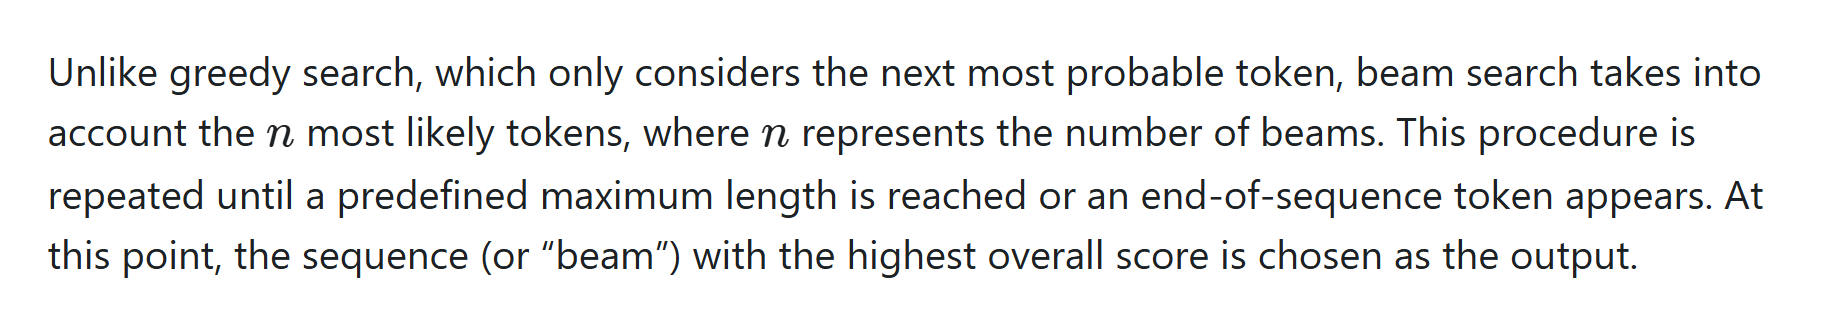

In [32]:
def plot_prob_distribution(probabilities, next_tokens, sampling, potential_nb, total_nb=50):
    # Get top k tokens
    top_k_prob, top_k_indices = torch.topk(probabilities, total_nb)
    top_k_tokens = [tokenizer.decode([idx]) for idx in top_k_indices.tolist()]

    # Get next tokens and their probabilities
    next_tokens_list = [tokenizer.decode([idx]) for idx in next_tokens.tolist()]
    next_token_prob = probabilities[next_tokens].tolist()

    # Create figure
    plt.figure(figsize=(0.4*total_nb, 5), dpi=300, facecolor='white')
    plt.rc('axes', axisbelow=True)
    plt.grid(axis='y', linestyle='-', alpha=0.5)
    if potential_nb < total_nb:
        plt.axvline(x=potential_nb-0.5, ls=':', color='grey', label='Sampled tokens')
    plt.bar(top_k_tokens, top_k_prob.tolist(), color='blue')
    plt.bar(next_tokens_list, next_token_prob, color='red', label='Selected tokens')
    plt.xticks(rotation=45, ha='right', va='top')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if sampling == 'top_k':
        plt.title('Probability distribution of predicted tokens with top-k sampling')
    elif sampling == 'nucleus':
        plt.title('Probability distribution of predicted tokens with nucleus sampling')
    plt.legend()
    plt.savefig(f'{sampling}_{time.time()}.png', dpi=300)
    plt.close()

def top_k_sampling(logits, temperature, top_k, beams, plot=True):
    assert top_k >= 1
    assert beams <= top_k

    indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
    new_logits = torch.clone(logits)
    new_logits[indices_to_remove] = float('-inf')

    # Convert logits to probabilities
    probabilities = torch.nn.functional.softmax(new_logits / temperature, dim=-1)

    # Sample n tokens from the resulting distribution
    next_tokens = torch.multinomial(probabilities, beams)

    # Plot distribution
    if plot:
        total_prob = torch.nn.functional.softmax(logits / temperature, dim=-1)
        plot_prob_distribution(total_prob, next_tokens, 'top_k', top_k)

    return next_tokens

In [33]:
def nucleus_sampling(logits, temperature, p, beams, plot=True):
    assert p > 0
    assert p <= 1

    # Sort the probabilities in descending order and compute cumulative probabilities
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    probabilities = torch.nn.functional.softmax(sorted_logits / temperature, dim=-1)
    cumulative_probabilities = torch.cumsum(probabilities, dim=-1)

    # Create a mask for probabilities that are in the top-p
    mask = cumulative_probabilities < p

    # If there's not n index where cumulative_probabilities < p, we use the top n tokens instead
    if mask.sum() > beams:
        top_p_index_to_keep = torch.where(mask)[0][-1].detach().cpu().tolist()
    else:
        top_p_index_to_keep = beams

    # Only keep top-p indices
    indices_to_remove = sorted_indices[top_p_index_to_keep:]
    sorted_logits[indices_to_remove] = float('-inf')

    # Sample n tokens from the resulting distribution
    probabilities = torch.nn.functional.softmax(sorted_logits / temperature, dim=-1)
    next_tokens = torch.multinomial(probabilities, beams)

    # Plot distribution
    if plot:
        total_prob = torch.nn.functional.softmax(logits / temperature, dim=-1)
        plot_prob_distribution(total_prob, next_tokens, 'nucleus', top_p_index_to_keep)

    return next_tokens

In [34]:
from tqdm.notebook import tqdm

def greedy_sampling(logits, beams):
    return torch.topk(logits, beams).indices
    
def beam_search(input_ids, node, bar, length, beams, sampling, temperature=0.1):
    if length == 0:
        return None

    outputs = model(input_ids)
    predictions = outputs.logits

    # Get the predicted next sub-word (here we use top-k search)
    logits = predictions[0, -1, :]

    if sampling == 'greedy':
        top_token_ids = greedy_sampling(logits, beams)
    elif sampling == 'top_k':
        top_token_ids = top_k_sampling(logits, temperature, 20, beams)
    elif sampling == 'nucleus':
        top_token_ids = nucleus_sampling(logits, temperature, 0.5, beams)

    for j, token_id in enumerate(top_token_ids):
        bar.update(1)

        # Compute the score of the predicted token
        token_score = get_log_prob(logits, token_id)
        cumulative_score = graph.nodes[node]['cumscore'] + token_score

        # Add the predicted token to the list of input ids
        new_input_ids = torch.cat([input_ids, token_id.unsqueeze(0).unsqueeze(0)], dim=-1)

        # Add node and edge to graph
        token = tokenizer.decode(token_id, skip_special_tokens=True)
        current_node = list(graph.successors(node))[j]
        graph.nodes[current_node]['tokenscore'] = np.exp(token_score) * 100
        graph.nodes[current_node]['cumscore'] = cumulative_score
        graph.nodes[current_node]['sequencescore'] = 1/(len(new_input_ids.squeeze())) * cumulative_score
        graph.nodes[current_node]['token'] = token + f"_{length}_{j}"

        # Recursive call
        beam_search(new_input_ids, current_node, bar, length-1, beams, sampling, 1)

# Parameters
length = 5
beams = 2

# Create a balanced tree with height 'length' and branching factor 'k'
graph = nx.balanced_tree(beams, length, create_using=nx.DiGraph())
bar = tqdm(total=len(graph.nodes))

# Add 'tokenscore', 'cumscore', and 'token' attributes to each node
for node in graph.nodes:
    graph.nodes[node]['tokenscore'] = 100
    graph.nodes[node]['cumscore'] = 0
    graph.nodes[node]['sequencescore'] = 0
    graph.nodes[node]['token'] = text

# Start generating text
beam_search(input_ids, 0, bar, length, beams, 'greedy', 1)

  0%|          | 0/63 [00:00<?, ?it/s]

In [40]:
def get_best_sequence(G):
    # Create a list of leaf nodes
    leaf_nodes = [node for node in G.nodes() if G.out_degree(node)==0]

    # Get the leaf node with the highest cumscore
    max_score_node = None
    max_score = float('-inf')
    for node in leaf_nodes:
        if G.nodes[node]['sequencescore'] > max_score:
            max_score = G.nodes[node]['sequencescore']
            max_score_node = node

    # Retrieve the sequence of nodes from this leaf node to the root node in a list
    path = nx.shortest_path(G, source=0, target=max_score_node)

    # Return the string of token attributes of this sequence
    sequence = "".join([G.nodes[node]['token'].split('_')[0] for node in path])
    
    return sequence, max_score

sequence, max_score = get_best_sequence(graph)
print(f"Generated text: {sequence}")

Generated text: I have a dream.

I have


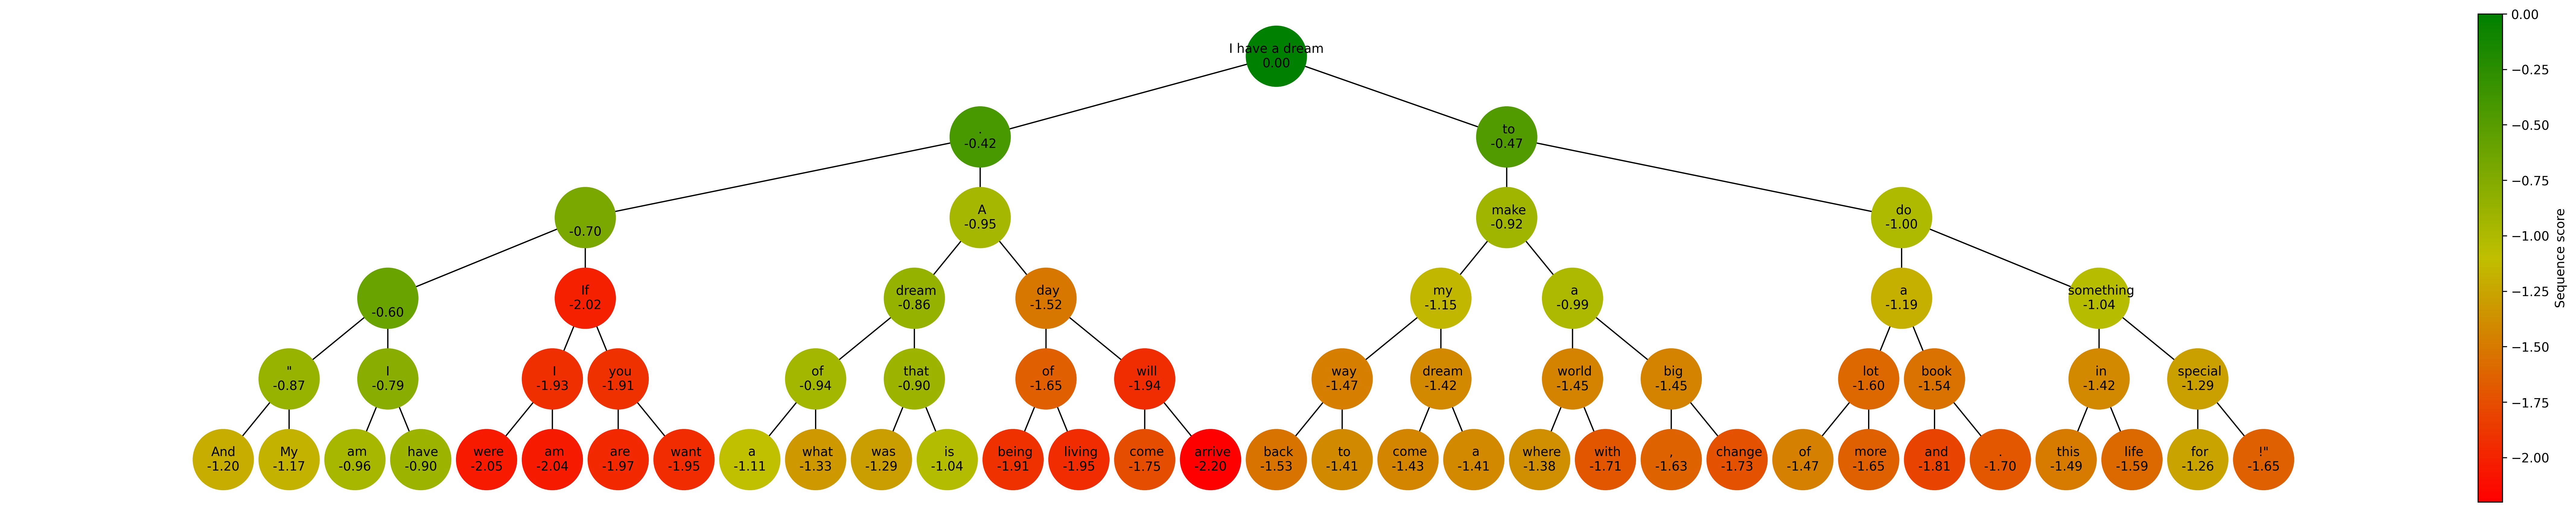

In [42]:
# Plot graph
plot_graph(graph, length, beams, 'sequence')

In [36]:
# Start generating text
beam_search(input_ids, 0, bar, length, beams, 'nucleus', 1)

In [37]:
def get_best_sequence(G):
    # Create a list of leaf nodes
    leaf_nodes = [node for node in G.nodes() if G.out_degree(node)==0]

    # Get the leaf node with the highest cumscore
    max_score_node = None
    max_score = float('-inf')
    for node in leaf_nodes:
        if G.nodes[node]['sequencescore'] > max_score:
            max_score = G.nodes[node]['sequencescore']
            max_score_node = node

    # Retrieve the sequence of nodes from this leaf node to the root node in a list
    path = nx.shortest_path(G, source=0, target=max_score_node)

    # Return the string of token attributes of this sequence
    sequence = "".join([G.nodes[node]['token'].split('_')[0] for node in path])
    
    return sequence, max_score

sequence, max_score = get_best_sequence(graph)
print(f"Generated text: {sequence}")

Generated text: I have a dream. I have a dream


In [38]:
# Start generating text
beam_search(input_ids, 0, bar, length, beams, 'top_k', 1)

In [39]:
def get_best_sequence(G):
    # Create a list of leaf nodes
    leaf_nodes = [node for node in G.nodes() if G.out_degree(node)==0]

    # Get the leaf node with the highest cumscore
    max_score_node = None
    max_score = float('-inf')
    for node in leaf_nodes:
        if G.nodes[node]['sequencescore'] > max_score:
            max_score = G.nodes[node]['sequencescore']
            max_score_node = node

    # Retrieve the sequence of nodes from this leaf node to the root node in a list
    path = nx.shortest_path(G, source=0, target=max_score_node)

    # Return the string of token attributes of this sequence
    sequence = "".join([G.nodes[node]['token'].split('_')[0] for node in path])
    
    return sequence, max_score

sequence, max_score = get_best_sequence(graph)
print(f"Generated text: {sequence}")

Generated text: I have a dream.

I have


In [43]:
from tqdm.notebook import tqdm

def greedy_sampling(logits, beams):
    return torch.topk(logits, beams).indices
    
def beam_search(input_ids, node, bar, length, beams, sampling, temperature=0.1):
    if length == 0:
        return None

    outputs = model(input_ids)
    predictions = outputs.logits

    # Get the predicted next sub-word (here we use top-k search)
    logits = predictions[0, -1, :]

    if sampling == 'greedy':
        top_token_ids = greedy_sampling(logits, beams)
    elif sampling == 'top_k':
        top_token_ids = top_k_sampling(logits, temperature, 20, beams)
    elif sampling == 'nucleus':
        top_token_ids = nucleus_sampling(logits, temperature, 0.5, beams)

    for j, token_id in enumerate(top_token_ids):
        bar.update(1)

        # Compute the score of the predicted token
        token_score = get_log_prob(logits, token_id)
        cumulative_score = graph.nodes[node]['cumscore'] + token_score

        # Add the predicted token to the list of input ids
        new_input_ids = torch.cat([input_ids, token_id.unsqueeze(0).unsqueeze(0)], dim=-1)

        # Add node and edge to graph
        token = tokenizer.decode(token_id, skip_special_tokens=True)
        current_node = list(graph.successors(node))[j]
        graph.nodes[current_node]['tokenscore'] = np.exp(token_score) * 100
        graph.nodes[current_node]['cumscore'] = cumulative_score
        graph.nodes[current_node]['sequencescore'] = 1/(len(new_input_ids.squeeze())) * cumulative_score
        graph.nodes[current_node]['token'] = token + f"_{length}_{j}"

        # Recursive call
        beam_search(new_input_ids, current_node, bar, length-1, beams, sampling, 1)

# Parameters
length = 5
beams = 2

# Create a balanced tree with height 'length' and branching factor 'k'
graph = nx.balanced_tree(beams, length, create_using=nx.DiGraph())
bar = tqdm(total=len(graph.nodes))

# Add 'tokenscore', 'cumscore', and 'token' attributes to each node
for node in graph.nodes:
    graph.nodes[node]['tokenscore'] = 100
    graph.nodes[node]['cumscore'] = 0
    graph.nodes[node]['sequencescore'] = 0
    graph.nodes[node]['token'] = text

# Start generating text
beam_search(input_ids, 0, bar, length, beams, 'greedy', 1)

  0%|          | 0/63 [00:00<?, ?it/s]

In [44]:
def get_best_sequence(G):
    # Create a list of leaf nodes
    leaf_nodes = [node for node in G.nodes() if G.out_degree(node)==0]

    # Get the leaf node with the highest cumscore
    max_score_node = None
    max_score = float('-inf')
    for node in leaf_nodes:
        if G.nodes[node]['sequencescore'] > max_score:
            max_score = G.nodes[node]['sequencescore']
            max_score_node = node

    # Retrieve the sequence of nodes from this leaf node to the root node in a list
    path = nx.shortest_path(G, source=0, target=max_score_node)

    # Return the string of token attributes of this sequence
    sequence = "".join([G.nodes[node]['token'].split('_')[0] for node in path])
    
    return sequence, max_score

sequence, max_score = get_best_sequence(graph)
print(f"Generated text: {sequence}")

Generated text: I have a dream. I have a dream


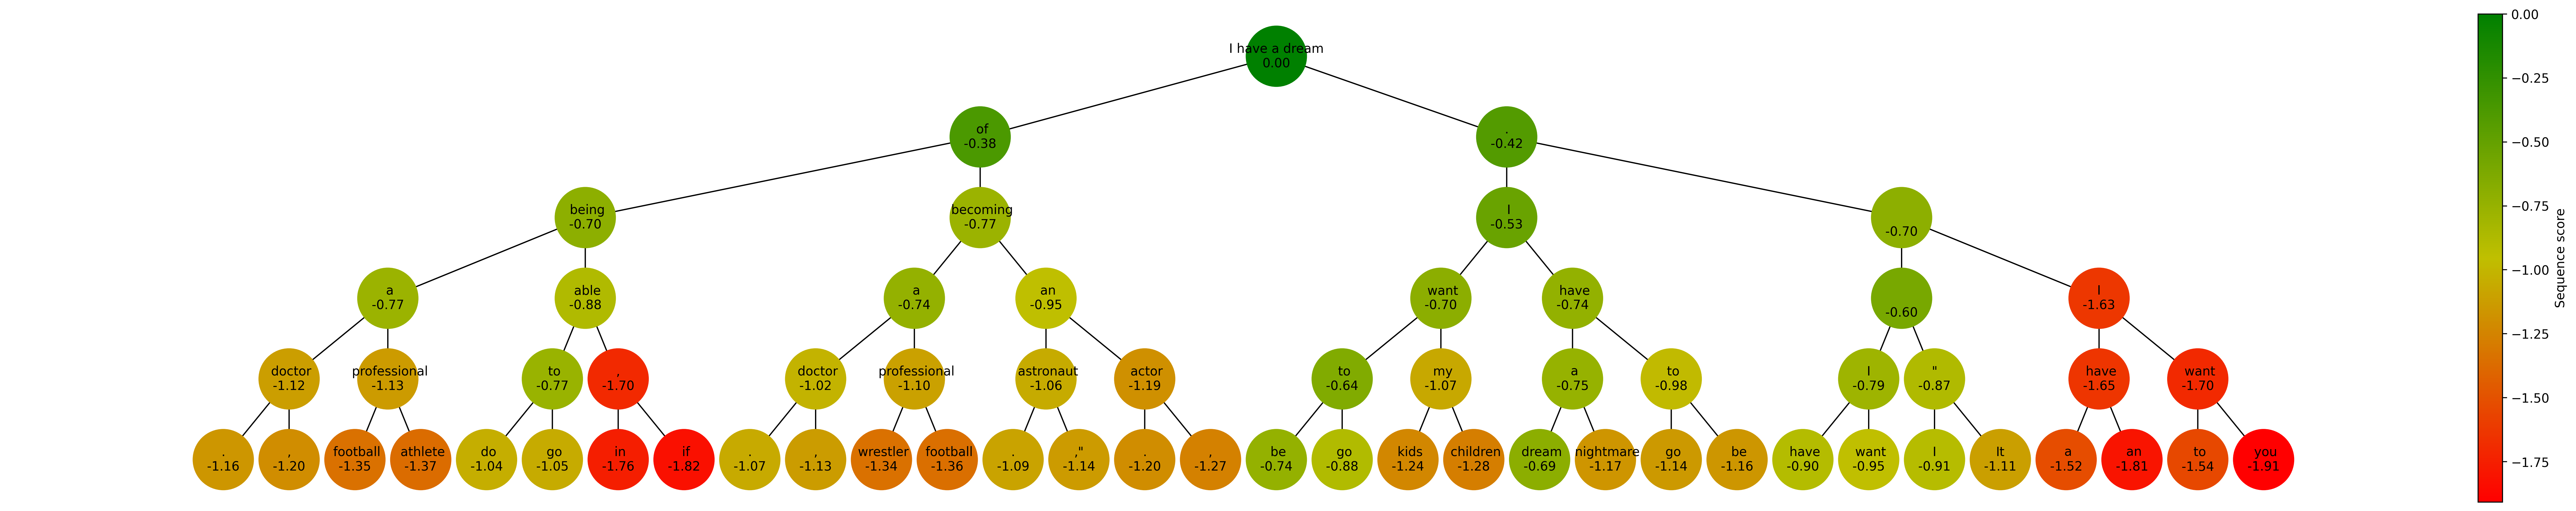

In [45]:
# Plot graph
plot_graph(graph, length, beams, 'sequence')

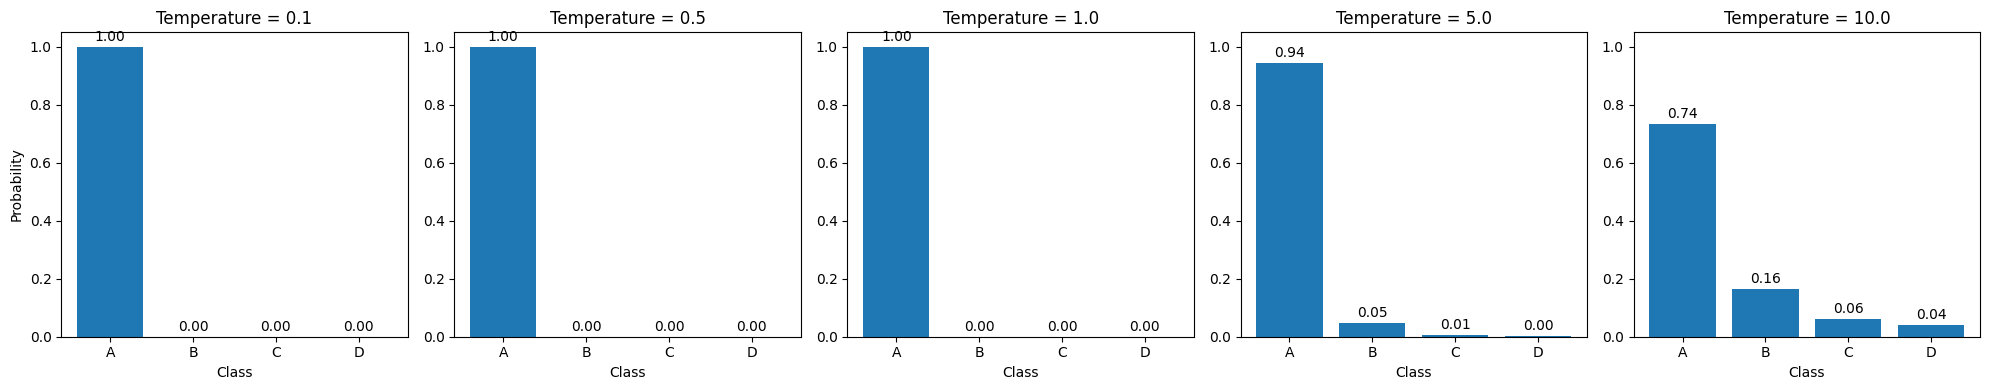

In [46]:
import torch
import matplotlib.pyplot as plt

logits = torch.tensor([30.0, 15.0, 5.0, 1.0])
classes = ['A', 'B', 'C', 'D']

temperatures = [0.1, 0.5, 1.0, 5.0, 10.0]  # includes several T > 1, since T=0.1/0.5 collapse identically to T=1 here

fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))

for ax, T in zip(axes, temperatures):
    probs = torch.nn.functional.softmax(logits / T, dim=-1)
    bars = ax.bar(classes, probs.numpy())
    ax.set_title(f'Temperature = {T}')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Class')
    if ax is axes[0]:
        ax.set_ylabel('Probability')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, p.item() + 0.02,
                 f'{p.item():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('temperature_ABCD.png', dpi=150)
plt.show()

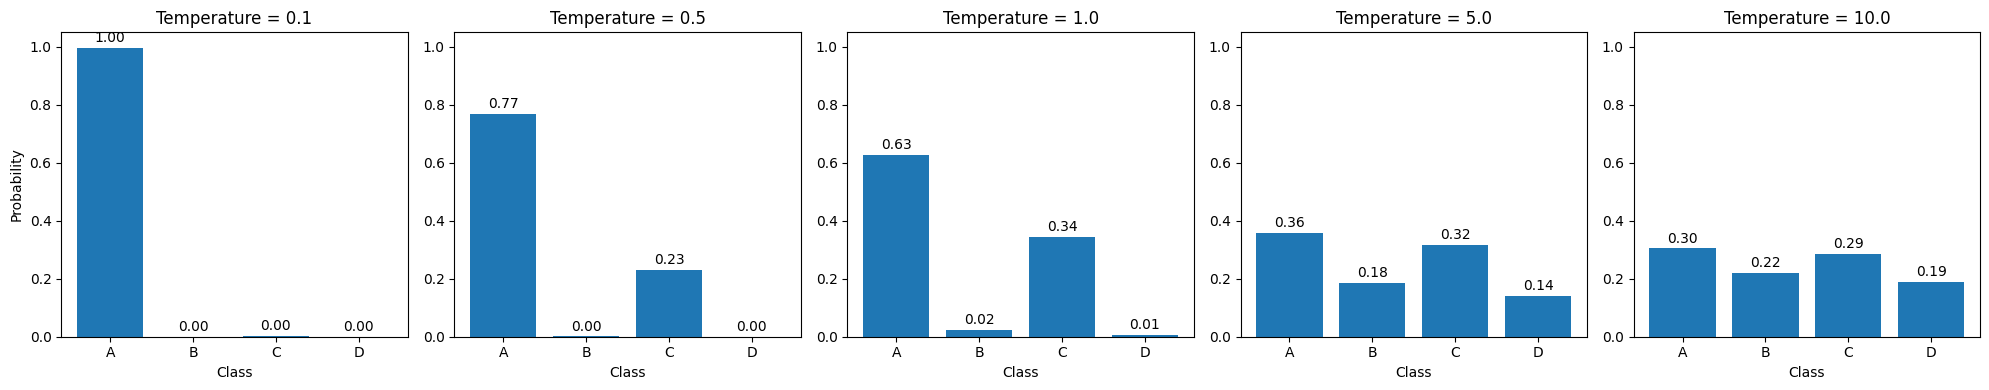

In [49]:
logits = torch.tensor([1.5, -1.8, 0.9, -3.2])
classes = ['A', 'B', 'C', 'D']

temperatures = [0.1, 0.5, 1.0, 5.0, 10.0]  # includes several T > 1, since T=0.1/0.5 collapse identically to T=1 here

fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))

for ax, T in zip(axes, temperatures):
    probs = torch.nn.functional.softmax(logits / T, dim=-1)
    bars = ax.bar(classes, probs.numpy())
    ax.set_title(f'Temperature = {T}')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Class')
    if ax is axes[0]:
        ax.set_ylabel('Probability')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, p.item() + 0.02,
                 f'{p.item():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('temperature_ABCD.png', dpi=150)
plt.show()

#### Top K sampling

In [3]:
import torch

In [4]:
def top_k_sampling(logits, temperature, top_k, beams):
    # 1. Scale by temperature
    scaled_logits = logits / temperature

    # 2. Truncate to top-k candidates only
    top_k_logits, top_k_indices = torch.topk(scaled_logits, top_k)

    # 3. Softmax over just those top-k logits (not the full vocabulary)
    top_k_probs = torch.nn.functional.softmax(top_k_logits, dim=-1)

    # 4. Sample `beams` distinct tokens from this truncated distribution
    sampled_relative_indices = torch.multinomial(top_k_probs, beams, replacement=False)

    # sampled_relative_indices are positions WITHIN the top-k slice (0 to top_k-1),
    # not real vocabulary token IDs — map them back to actual token IDs
    token_ids = top_k_indices[sampled_relative_indices]

    return token_ids

In [5]:
torch.manual_seed(0)
logits = torch.tensor([10.0, 9.5, 8.0, 6.0, 4.0, 2.0, 1.0, 0.5])
token_ids = top_k_sampling(logits, temperature=1.0, top_k=4, beams=2)
print(token_ids)  # should only ever contain indices 0, 1, 2, or 3 — never 4-7, since top_k=4 excludes them

tensor([1, 0])


In [6]:
def sample_with_temperature(logits: torch.Tensor, temperature: float = 1.0):
    """Pure temperature sampling — no truncation, samples from the full vocab."""
    scaled_logits = logits / temperature
    probs = torch.nn.functional.softmax(scaled_logits, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1)
    return next_token


def sample_top_k(logits: torch.Tensor, temperature: float = 1.0, top_k: int = 20):
    """Top-k + temperature sampling — mask out everything outside the top_k, then sample."""
    assert top_k >= 1
    indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
    new_logits = torch.clone(logits)
    new_logits[indices_to_remove] = float('-inf')

    probs = torch.nn.functional.softmax(new_logits / temperature, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1)
    return next_token


def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 20,
    temperature: float = 1.0,
    top_k: int = None,
    seed: int = None,
):
    """
    Autoregressive generation loop using temperature and/or top-k sampling.

    - top_k=None            -> pure temperature sampling over the full vocab
    - top_k=<int>            -> top-k + temperature sampling (combined)
    - temperature=1.0, top_k=None -> equivalent to plain multinomial sampling
    """
    if seed is not None:
        torch.manual_seed(seed)

    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)

        logits = outputs.logits[0, -1, :]  # last position only, shape [vocab_size]

        if top_k is not None:
            next_token = sample_top_k(logits, temperature=temperature, top_k=top_k)
        else:
            next_token = sample_with_temperature(logits, temperature=temperature)

        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=-1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(input_ids.squeeze().tolist(), skip_special_tokens=True)


# --- Usage with your HuggingFace GPT model ---
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

prompt = "The scientist looked at the data and"

# Pure temperature sampling
print(generate(model, tokenizer, prompt, temperature=0.7, seed=0))

# Top-k combined with temperature
print(generate(model, tokenizer, prompt, temperature=0.7, top_k=40, seed=0))

# High temperature, no top-k restriction (more random)
print(generate(model, tokenizer, prompt, temperature=1.5, seed=0))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The scientist looked at the data and found that the more active the person is, the longer it takes for that person to react to the
The scientist looked at the data and found that the more active the person is, the longer it takes for that person to react to the
The scientist looked at the data and along came seven more perturbations isbacks at neutron diffuse the spill that the central cooling ensemble wrestler


In [ ]:
model_name = "gpt2"
# pip install transformers torch --break-system-packages   (if not already installed)

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "gpt2"  # small, fast, good for experimenting
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

prompt = "The scientist looked at the data and"
inputs = tokenizer(prompt, return_tensors="pt")

def generate(**kwargs):
    torch.manual_seed(0)  # reproducibility for sampling-based methods
    output = model.generate(**inputs, max_new_tokens=len(inputs) + 20, pad_token_id=tokenizer.eos_token_id, **kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

print(generate(do_sample=True, top_k = 40, temperature=0.7))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The scientist looked at the data and found that the more active the person is, the longer it takes for that person to react to the threat.


In [ ]:
print(generate(do_sample=True, top_k = 40, temperature=1.5))

The scientist looked at the data and found that their body shape had an impact on the way the body moves through the physical dimension, while people with


In [61]:
print(generate(do_sample=True, temperature=1.5))

The scientist looked at the data and found that their body shape had taken the "up step from the normal" up level and moved out towards a


In [7]:
sample_top_k(torch.tensor([10.0, 20.0, 30.0, 40.0]), temperature=1.0, top_k=2)

tensor([3])

In [8]:
def top_k_sampling(logits, temperature, top_k, beams):
    # 1. Scale by temperature
    scaled_logits = logits / temperature

    # 2. Truncate to top-k candidates only
    top_k_logits, top_k_indices = torch.topk(scaled_logits, top_k)

    # 3. Softmax over just those top-k logits (not the full vocabulary)
    top_k_probs = torch.nn.functional.softmax(top_k_logits, dim=-1)

    # 4. Sample `beams` distinct tokens from this truncated distribution
    sampled_relative_indices = torch.multinomial(top_k_probs, beams, replacement=False)

    # sampled_relative_indices are positions WITHIN the top-k slice (0 to top_k-1),
    # not real vocabulary token IDs — map them back to actual token IDs
    token_ids = top_k_indices[sampled_relative_indices]

    return token_ids

top_k_sampling(torch.tensor([10.0, 20.0, 30.0, 40.0]), temperature=1.0, top_k=2, beams=1)

tensor([3])

In [10]:
torch.topk(torch.tensor([10.0, 20.0, 30.0, 40.0]), k=2)

torch.return_types.topk(
values=tensor([40., 30.]),
indices=tensor([3, 2]))

In [11]:
top_k_logits, top_k_index = torch.topk(torch.tensor([10.0, 20.0, 30.0, 40.0]), k=2)
top_k_logits

tensor([40., 30.])

In [14]:
torch.tensor([10.0, 20.0, 30.0, 40.0]) < torch.topk(torch.tensor([10.0, 20.0, 30.0, 40.0]), k=2)[0][..., 1, None]

tensor([ True,  True, False, False])

In [16]:
mask = torch.tensor([10.0, 20.0, 30.0, 40.0]) < torch.topk(torch.tensor([10.0, 20.0, 30.0, 40.0]), k=2)[0][..., 1, None]
new_logits = torch.tensor([10.0, 20.0, 30.0, 40.0])[mask]
new_logits

tensor([10., 20.])

In [19]:
logits = torch.tensor([10.0, 20.0, 30.0, 40.0])
new_logits = logits.clone()

new_logits[mask] = float("-inf")
new_logits

tensor([-inf, -inf, 30., 40.])

In [20]:
probs = torch.nn.functional.softmax(new_logits / 1, dim=-1)
next_token = torch.multinomial(probs, num_samples=1)

In [21]:
next_token

tensor([3])

In [23]:
probs

tensor([0.0000e+00, 0.0000e+00, 4.5398e-05, 9.9995e-01])

In [25]:
from huggingface_hub import whoami
try:
    print(whoami())
except Exception as e:
    print("Not authenticated:", e)

{'type': 'user', 'id': '67e404063e29e70563654d90', 'name': 'oladipupo28', 'fullname': 'Taofeek Opeyemi Olawoye', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1788220800, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/Xug2Zvzavvn8Itj3P03o6.png', 'orgs': [{'type': 'org', 'id': '681b0cb0dba891d54be0773d', 'name': 'context-course', 'fullname': 'Hugging Face Context Course', 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/62d648291fa3e4e7ae3fa6e8/Rv0Bz5uHKIjSjzaNmykya.png'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'langchain', 'role': 'fineGrained', 'createdAt': '2026-08-09T11:29:22.276Z', 'fineGrained': {'canReadGatedRepos': True, 'global': ['discussion.write', 'post.write'], 'scoped': [{'entity': {'_id': '67e404063e29e70563654d90', 'type': 'user', 'name': 'oladipupo28'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write', 'inference.serverless.write', 'inference.en

In [26]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", device_map="auto")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

c:\Users\user\Documents\DeepLearning-Indepth\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [33]:
prompt = "The scientist looked at the data and"
inputs = tokenizer(prompt, return_tensors="pt")

def generate(**kwargs):
    torch.manual_seed(0)  # reproducibility for sampling-based methods
    output = model.generate(**inputs, max_new_tokens=len(inputs) + 1000, pad_token_id=tokenizer.eos_token_id, **kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

print(generate(do_sample=True, top_k = 40, temperature=0.7))

The scientist looked at the data and decided to take a closer look. He discovered that the growth of the plant was not uniform, but rather varied in different parts of the stem. To analyze this further, he divided the stem into three equal sections: top, middle, and bottom. He found out that the top section grew by 15 cm, the middle section grew by 20 cm, and the bottom section grew by 10 cm.

If the original length of the stem was 30 cm, how much longer is the stem after it has grown according to these measurements? Also, if the stem grows uniformly (i.e., each section grows equally), what would its new length be?

To determine how much longer the stem is after it has grown according to the given measurements, we need to calculate the total growth for each section and then add it to the original length of the stem.

First, let's find the total growth:
- The top section grew by \(15\) cm.
- The middle section grew by \(20\) cm.
- The bottom section grew by \(10\) cm.

Adding these toge

In [34]:
prompt = "Artificial Inteligence is"
inputs = tokenizer(prompt, return_tensors="pt")
print(generate(do_sample=True, top_k=40, temperature=0.7))

Artificial Inteligence is the future of every business and this is one of the major reasons why businesses are investing heavily in AI. It’s not only about making products smarter but also to understand customer behavior, optimize processes and improve overall performance.
In this blog post, we will discuss some of the benefits that Artificial Intelligence can bring into your business.
1. Improved Productivity
The most important benefit of AI for businesses is improved productivity. With the help of artificial intelligence, companies can automate repetitive tasks, freeing up time for employees to focus on more complex tasks.
AI-powered chatbots can answer frequently asked questions, reducing the need for human agents to handle simple inquiries. This allows sales teams to spend more time with customers, providing personalized service and increasing revenue.
2. Increased Efficiency
AI helps businesses increase efficiency by automating routine and time-consuming tasks. For example, an AI 

In [42]:
def generate(**kwargs):
    torch.manual_seed(0)
    output = model.generate(
        **inputs,
        max_new_tokens=len(inputs) + 500,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True,   # explicit, though it's the default
        **kwargs
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

import time 
start_time = time.time()
print(generate(do_sample=True, top_k = 40, temperature=0.7))
end_time = time.time()

print(f"The time taken using KV Cache: {end_time - start_time}")

Artificial Intelligence is the future of every industry and there are several ways in which it can be used. The first step towards understanding AI is to know what it means.
AI, or artificial intelligence, refers to a machine that is capable of performing tasks without human intervention. This technology has been around for many years but has only recently become more advanced with the help of computer algorithms and machine learning techniques.
There are several applications of AI in different industries including healthcare, finance, transportation, manufacturing, retail, and entertainment among others. These technologies have made our lives easier by providing us with better services and products. For instance, self-driving cars use AI to navigate roads safely while virtual assistants like Siri and Alexa use AI to provide users with information and perform tasks on their behalf.
In conclusion, AI is an essential tool that will continue to shape the world we live in. As technology co

In [44]:
prompt = "Artificial Intelligence is"
inputs = tokenizer(prompt, return_tensors="pt")

def generate_without_cache(**kwargs):
    torch.manual_seed(0)
    output = model.generate(
        **inputs,
        max_new_tokens=len(inputs) + 50,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=False,   # ← this line was missing
        **kwargs
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

import time 
start_time = time.time()
print(generate_without_cache(do_sample=True, top_k = 40, temperature=0.7))
end_time = time.time()

print(f"The time taken without using KV Cache: {end_time - start_time}")

KeyboardInterrupt: 